In [ ]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import pickle

In [ ]:
!pip install ecos
!pip install scs

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from google.colab import drive

# BƯỚC 1: Kết nối Google Drive (chỉ cần chạy 1 lần)
drive.mount('/content/drive', force_remount=True)

# BƯỚC 2: Cập nhật đường dẫn FACTOR_DIR
# Giả sử bạn đặt thư mục "valuation_out_23h_sigmoid"
# ngay trong "My Drive" (Drive của tôi)
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"

# --- Code của bạn bắt đầu từ đây ---
try:
    U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
    P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
    valuations = U @ P.T
    print(f"✓ Đã tải xong factors. Ma trận Valuations có shape: {valuations.shape}")

except Exception as e:
    print(f"⚠️  Lỗi khi tải file: {e}")
    print("Sử dụng ma trận valuations ngẫu nhiên...")
    valuations = np.random.rand(120, 12) + 0.5         # 120 buyers, 12 goods

obj_tol = 1e-3
num_iters = 10 ** 100
log_freq  = 100
X_tol   = 1e-5
seed = 2001
timE = 7200

print(f"\nThiết lập hoàn tất.")

Mounted at /content/drive
✓ Đã tải xong factors. Ma trận Valuations có shape: (10, 24)

Thiết lập hoàn tất.


In [ ]:
def build_A_matrix(n_goods, n_slots):
    A = np.zeros((n_slots, n_goods))
    for j in range(n_goods):
        A[j % n_slots, j] = 1.0
    return A

def buyer_best_response_cvx(v_i, p, A, q_i, B_i, utility_type="Linear"):
    """
    Phiên bản siêu tốc của buyer_best_response.
    Sử dụng Closed-form solution cho mọi hàm utility.
    KHÔNG DÙNG CVXPY.
    """
    # 1. Tính giá hiệu dụng (Effective Price)
    # p: (M,), A.T @ q_i: (M,)
    effective_price = p + (A.T @ q_i)

    # An toàn: Đảm bảo giá > 0 để tránh chia cho 0
    safe_price = np.maximum(effective_price, 1e-9)

    m_goods = len(v_i)
    x = np.zeros(m_goods)

    # =========================================================
    # 1. LINEAR UTILITY: U = sum(v * x)
    # =========================================================
    if utility_type == "Linear":
        # Chiến thuật: Bang-per-buck (Mua tất tay món hời nhất)
        bang_per_buck = v_i / safe_price
        best_idx = np.argmax(bang_per_buck)
        x[best_idx] = B_i / safe_price[best_idx]

    # =========================================================
    # 2. COBB-DOUGLAS: U = prod(x^alpha) hoặc sum(alpha * log(x))
    # =========================================================
    elif utility_type == "Cobb-Douglas":
        # Chuẩn hóa alpha (Bắt buộc để thỏa mãn Budget constraint)
        sum_v = np.sum(v_i)
        if sum_v > 0:
            alpha = v_i / sum_v
        else:
            alpha = np.zeros_like(v_i) # Tránh lỗi nếu v toàn 0

        # Công thức: Chi tiêu đúng tỷ lệ alpha
        # x_i = (alpha_i * Budget) / Price_i
        x = (alpha * B_i) / safe_price

    # =========================================================
    # 3. LEONTIEF: U = min(x / v)
    # =========================================================
    elif utility_type == "Leontief":
        # Chiến thuật: Mua theo tỷ lệ cố định của v
        # Giá của 1 combo chuẩn = sum(v_i * p_i)
        cost_of_one_bundle = np.dot(v_i, safe_price)

        if cost_of_one_bundle > 0:
            # Số lượng combo mua được
            num_bundles = B_i / cost_of_one_bundle
            x = num_bundles * v_i
        else:
            x = np.zeros(m_goods)

    # =========================================================
    # 4. CES UTILITY: U = (sum v * x^rho)^(1/rho)
    # =========================================================
    elif utility_type == "CES_8":
        # CẤU HÌNH rho (m) TẠI ĐÂY
        # Trong code cũ bạn để m = 1/2
        rho = 0.5

        # --- CASE A: CONCAVE (rho < 1, rho != 0) ---
        # Đây là trường hợp thay thế (Substitute) -> Mua nhiều loại
        if rho < 1:
            # Tính Sigma (Elasticity of Substitution)
            # sigma = 1 / (1 - rho)
            sigma = 1.0 / (1.0 - rho)

            # Tính phần tử tỷ lệ: Term_i = (v_i / p_i)^sigma
            # Dùng np.maximum cho v_i để tránh v=0 gây lỗi log hoặc mũ âm
            term = np.power(v_i / safe_price, sigma)

            # Tính mẫu số chung: Sum (p_j * term_j)
            denom = np.dot(safe_price, term)

            if denom > 0:
                # x_i = (B * term_i) / denom
                x = (B_i * term) / denom
            else:
                 # Fallback nếu v=0 hết
                 x = np.zeros(m_goods)

        # --- CASE B: CONVEX (rho > 1) ---
        # Đây là trường hợp "Winner Takes All" giống Linear
        else:
            # So sánh tỷ lệ: v^(1/rho) / p
            v_transformed = np.power(v_i, 1.0/rho)
            bang_per_buck = v_transformed / safe_price

            best_idx = np.argmax(bang_per_buck)
            x[best_idx] = B_i / safe_price[best_idx]

    return x

def one_sample_sgd_violation_tracking(
    A_algo, b_algo,      # A, b mà thuật toán ĐƯỢC THẤY
    A_true, b_true,      # A, b THẬT (để tính Violation)
    supply_s, q0, valuations, budgets, p0,
    lr_p=0.01, lr_q=0.01,
    num_iters=1000,
    seed=42,
    log_freq=10
):
    rng = np.random.default_rng(seed)
    n, m = valuations.shape

    p = p0.astype(float).copy()
    q = q0.astype(float).copy()

    # Warm start (Dựa trên cái thuật toán thấy)
    X = np.zeros((n, m)) * 1
    for j in range(n):
        X[j] = buyer_best_response_cvx(valuations[j], p, A_algo, q[j], budgets[j])

    D = X.sum(axis=0)
    violation_hist = []

    # Hàm tính Frobenius Norm của phần vi phạm dương
    def calc_frobenius_violation(X_curr):
        # Tính Load thực tế: (N, M) @ (M, T) -> (N, T)
        user_loads = X_curr @ A_true.T

        # Tính sai số: Load - Capacity
        diff = user_loads - b_true

        # Lọc phần tử > 0
        positive_violation = np.maximum(0, diff)

        # Tính Frobenius Norm
        return np.linalg.norm(positive_violation)

    # Ghi log t=0
    violation_hist.append(calc_frobenius_violation(X))

    print(f"--- Running SGD ({num_iters} iters)... ---")

    for t in range(1, num_iters + 1):
        i = int(rng.integers(n))

        D -= X[i]

        # Optimization dùng A_algo
        x_new = buyer_best_response_cvx(valuations[i], p, A_algo, q[i], budgets[i], "Linear")

        X[i] = x_new
        D += x_new

        # Gradients
        g_p = D - supply_s

        # Gradient q tính dựa trên cái thuật toán thấy
        load_i_algo = A_algo @ x_new
        g_q_i = load_i_algo - b_algo[i]

        # Update (Decay LR)
        alpha = lr_p / np.sqrt(t)
        beta  = lr_q / np.sqrt(t)

        p = np.maximum(0, p + alpha * g_p)
        q[i] = np.maximum(0, q[i] + beta * g_q_i)

        if t % log_freq == 0:
            # Violation tính dựa trên A_true, b_true
            vio = calc_frobenius_violation(X)
            violation_hist.append(vio)

    return violation_hist

In [ ]:
N_USERS, M_GOODS = valuations.shape
N_USERS, M_GOODS = valuations.shape
T_SLOTS = 4

# --- B. CONFIG PARAMS ---
np.random.seed(1)

# [1] Budgets
budgets = np.ones(N_USERS) * 10
supply_s = np.random.uniform(5, 10, M_GOODS)

# CAPACITY THẬT (Ground Truth)
capacity_b_true = np.random.uniform(1, 4, (N_USERS, T_SLOTS))


# --- C. CHẠY THÍ NGHIỆM ---
p0 = np.ones(M_GOODS)
q0 = np.zeros((N_USERS, T_SLOTS))
NUM_ITERS = 1000000
LOG_FREQ = 1

In [ ]:
N_USERS, M_GOODS = valuations.shape
T_SLOTS = 4

# --- B. CONFIG PARAMS ---
np.random.seed(1)

# [1] Budgets
budgets = np.ones(N_USERS) * 10
supply_s = np.random.uniform(5, 10, M_GOODS)

# CAPACITY THẬT (Ground Truth)
capacity_b_true = np.random.uniform(1, 4, (N_USERS, T_SLOTS))

# MA TRẬN A THẬT
if M_GOODS % T_SLOTS == 0: A_true = build_A_matrix(M_GOODS, T_SLOTS)
else: A_true = np.zeros((T_SLOTS, M_GOODS))

# --- C. CHẠY THÍ NGHIỆM ---
p0 = np.ones(M_GOODS)
q0 = np.zeros((N_USERS, T_SLOTS))
NUM_ITERS = 1000000
LOG_FREQ = 1

# 1. BASELINE (BLIND MODE)
# Tạo A_dummy toàn số 0 -> Best Response không thấy constraint slots
# Tạo b_dummy toàn số 0 -> Gradient q sẽ sai (nhưng không quan trọng vì A=0 thì load=0)
print("\n[1] Running Baseline (Blind)...")
A_dummy = np.zeros_like(A_true)
b_dummy = np.zeros_like(capacity_b_true)

hist_baseline = one_sample_sgd_violation_tracking(
    A_algo=A_dummy, b_algo=b_dummy,      # <--- GIẢ MÙ: Thuật toán thấy A=0, b=0
    A_true=A_true, b_true=capacity_b_true, # <--- Ground Truth để tính Violation
    supply_s=supply_s, q0=q0, valuations=valuations, budgets=budgets, p0=p0,
    lr_p=0.02, lr_q=0,
    num_iters=NUM_ITERS, log_freq=LOG_FREQ
)

# 2. PROPOSED (AWARE MODE)
# Truyền A_true, b_true vào cho thuật toán optimization
print("\n[2] Running Proposed (Constraint Aware)...")
hist_proposed = one_sample_sgd_violation_tracking(
    A_algo=A_true, b_algo=capacity_b_true, # <--- Thấy Ràng Buộc Thật
    A_true=A_true, b_true=capacity_b_true,
    supply_s=supply_s, q0=q0, valuations=valuations, budgets=budgets, p0=p0,
    lr_p=0.02, lr_q=0.02,
    num_iters=NUM_ITERS, log_freq=LOG_FREQ
)


[1] Running Baseline (Blind)...
--- Running SGD (1000000 iters)... ---

[2] Running Proposed (Constraint Aware)...
--- Running SGD (1000000 iters)... ---


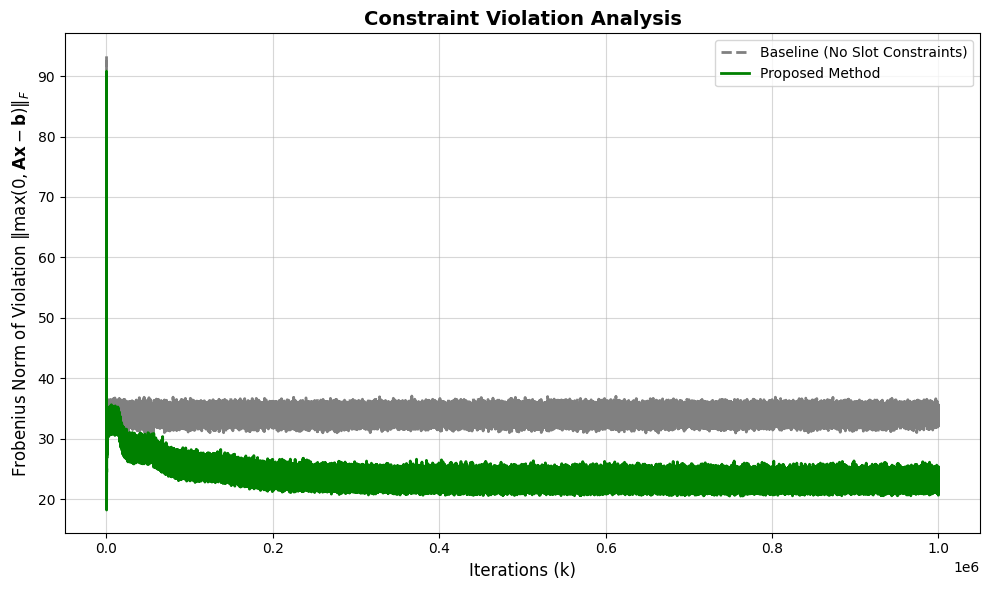

In [ ]:
# ==============================================================================
# 3. VẼ BIỂU ĐỒ
# ==============================================================================
plt.figure(figsize=(10, 6))

iterations = np.arange(len(hist_baseline)) * LOG_FREQ

# Vẽ Baseline
plt.plot(iterations, hist_baseline, color='gray', linestyle='--', linewidth=2, label='Baseline (No Slot Constraints)')

# Vẽ Proposed
plt.plot(iterations, hist_proposed, color='green', linewidth=2, label='Proposed Method')

plt.xlabel('Iterations (k)', fontsize=12)
plt.ylabel(r'Frobenius Norm of Violation $\|\max(0, \mathbf{Ax} - \mathbf{b})\|_F$', fontsize=12)
plt.title('Constraint Violation Analysis', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='-', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

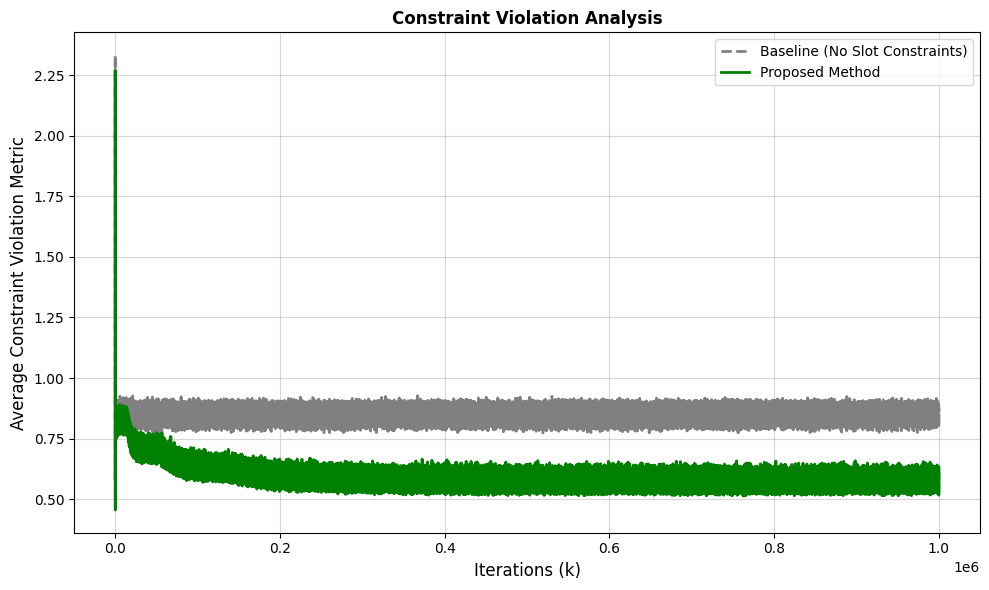

In [ ]:
denom = N_USERS * T_SLOTS
# ==============================================================================
# 3. VẼ BIỂU ĐỒ
# ==============================================================================
plt.figure(figsize=(10, 6))

iterations = np.arange(len(hist_baseline)) * LOG_FREQ

# Vẽ Baseline
plt.plot(iterations, np.array(hist_baseline) / denom, color='gray', linestyle='--', linewidth=2, label='Baseline (No Slot Constraints)')

# Vẽ Proposed
plt.plot(iterations, np.array(hist_proposed) / denom, color='green', linewidth=2, label='Proposed Method')

plt.xlabel('Iterations (k)', fontsize=12)
plt.ylabel('Average Constraint Violation Metric', fontsize=12)
plt.title('Constraint Violation Analysis', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='-', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

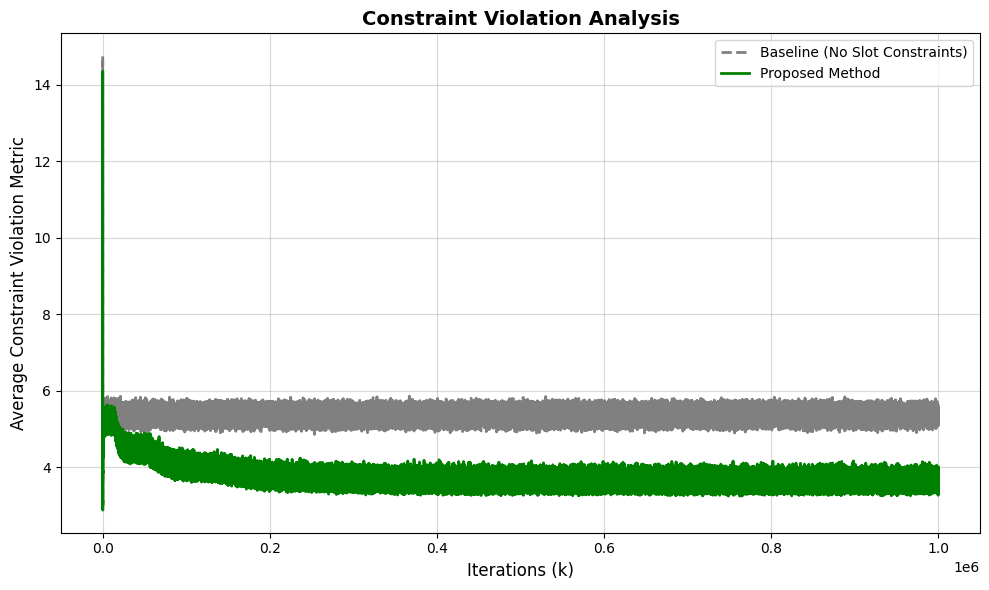

In [ ]:
denom = N_USERS * T_SLOTS
# ==============================================================================
# 3. VẼ BIỂU ĐỒ
# ==============================================================================
plt.figure(figsize=(10, 6))

iterations = np.arange(len(hist_baseline)) * LOG_FREQ

# Vẽ Baseline
plt.plot(iterations, np.array(hist_baseline) / np.sqrt(denom), color='gray', linestyle='--', linewidth=2, label='Baseline (No Slot Constraints)')

# Vẽ Proposed
plt.plot(iterations, np.array(hist_proposed) / np.sqrt(denom), color='green', linewidth=2, label='Proposed Method')

plt.xlabel('Iterations (k)', fontsize=12)
plt.ylabel('Average Constraint Violation Metric', fontsize=12)
plt.title('Constraint Violation Analysis', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='-', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
save_dir = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig2"

# Tạo thư mục nếu chưa tồn tại
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Đã tạo thư mục: {save_dir}")

# Lưu obj_hist vào file pickle
file_path = os.path.join(save_dir, "hist_baseline_fig2.pkl")

with open(file_path, 'wb') as f:
    pickle.dump(hist_baseline, f)

print(f"✅ Đã lưu thành công obj_hist tại: {file_path}")

✅ Đã lưu thành công obj_hist tại: /content/drive/MyDrive/EV_charging_project/experiment_results/Fig2/hist_baseline_fig2.pkl


In [ ]:
save_dir = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig2"

# Tạo thư mục nếu chưa tồn tại
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Đã tạo thư mục: {save_dir}")

# Lưu obj_hist vào file pickle
file_path = os.path.join(save_dir, "hist_proposed_fig2.pkl")

with open(file_path, 'wb') as f:
    pickle.dump(hist_proposed, f)

print(f"✅ Đã lưu thành công obj_hist tại: {file_path}")

✅ Đã lưu thành công obj_hist tại: /content/drive/MyDrive/EV_charging_project/experiment_results/Fig2/hist_proposed_fig2.pkl


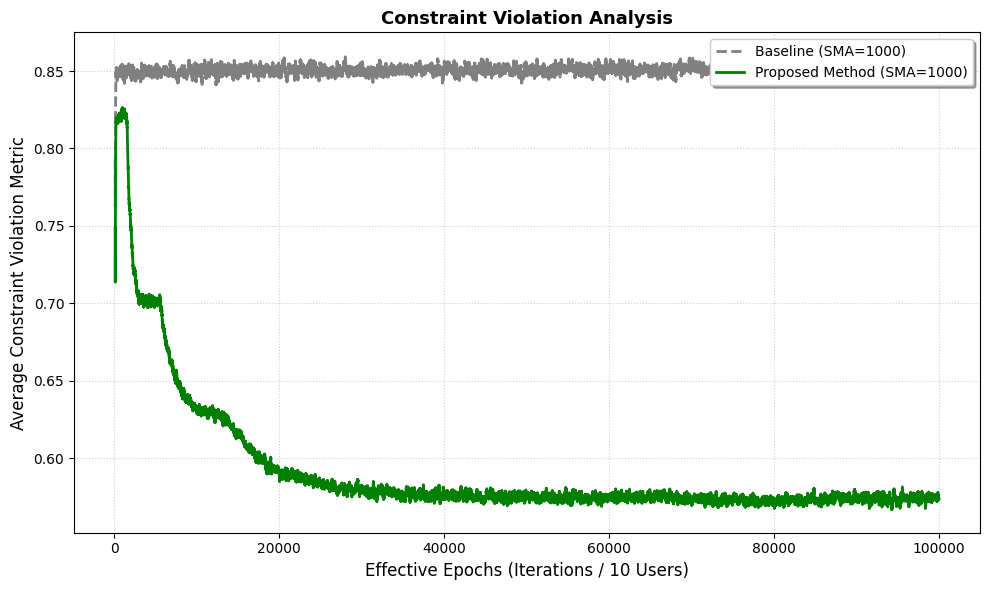

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# CẤU HÌNH BIỂU ĐỒ
# ==============================================================================
denom = N_USERS * T_SLOTS
WINDOW_SIZE = 1000   # <--- CHỈNH ĐỘ MƯỢT TẠI ĐÂY (Số càng lớn đường càng mượt)
USERS_FOR_EPOCH = 10 # Số user dùng để chia trục X

# Hàm tính Moving Average
def moving_average(data, window_size):
    if window_size <= 1:
        return data
    # mode='valid': Chỉ lấy những điểm tính đủ window, loại bỏ phần rìa thiếu dữ liệu
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# ==============================================================================
# XỬ LÝ DỮ LIỆU
# ==============================================================================

# 1. Tính toán dữ liệu gốc (Normalized)
y_baseline_raw = np.array(hist_baseline) / denom
y_proposed_raw = np.array(hist_proposed) / denom

# 2. Áp dụng SMA (Làm mượt)
y_baseline_smooth = moving_average(y_baseline_raw, WINDOW_SIZE)
y_proposed_smooth = moving_average(y_proposed_raw, WINDOW_SIZE)

# 3. Xử lý Trục X (Effective Epochs)
# Tạo mảng Iterations gốc
raw_iterations = np.arange(len(hist_baseline)) * LOG_FREQ

# Chuyển đổi sang Epochs
epochs_raw = raw_iterations / USERS_FOR_EPOCH

# Cắt trục X cho khớp độ dài với dữ liệu sau khi làm mượt
# (SMA mode='valid' sẽ làm ngắn mảng đi window_size - 1 phần tử)
if WINDOW_SIZE > 1:
    epochs_plot = epochs_raw[WINDOW_SIZE-1:]
else:
    epochs_plot = epochs_raw

# ==============================================================================
# VẼ BIỂU ĐỒ
# ==============================================================================
plt.figure(figsize=(10, 6))

# Vẽ Baseline
plt.plot(epochs_plot, y_baseline_smooth,
         color='gray', linestyle='--', linewidth=2,
         label=f'Baseline (SMA={WINDOW_SIZE})')

# Vẽ Proposed
plt.plot(epochs_plot, y_proposed_smooth,
         color='green', linewidth=2,
         label=f'Proposed Method (SMA={WINDOW_SIZE})')

# Trang trí
plt.xlabel(f'Effective Epochs (Iterations / {USERS_FOR_EPOCH} Users)', fontsize=12)
plt.ylabel('Average Constraint Violation Metric', fontsize=12)
plt.title('Constraint Violation Analysis', fontsize=13, fontweight='bold')

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fancybox=True, shadow=True, loc='upper right')

plt.tight_layout()
plt.show()

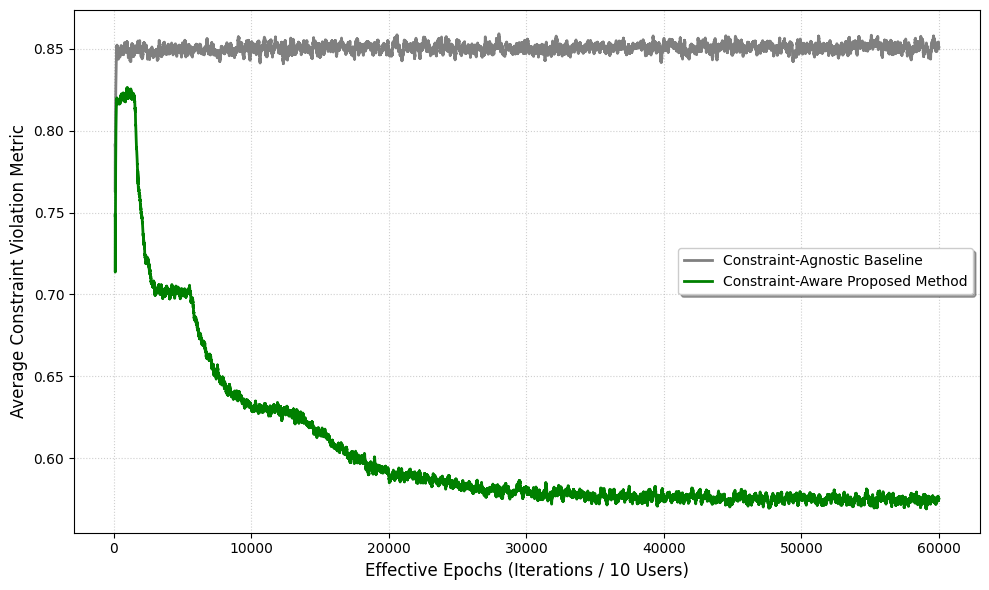

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# CẤU HÌNH BIỂU ĐỒ
# ==============================================================================
denom = N_USERS * T_SLOTS
WINDOW_SIZE = 1000
USERS_FOR_EPOCH = 10
EPOCH_LIMIT = 60000  # <--- [MỚI] Giới hạn Epoch mong muốn

# Hàm tính Moving Average
def moving_average(data, window_size):
    if window_size <= 1:
        return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# ==============================================================================
# XỬ LÝ DỮ LIỆU
# ==============================================================================

# 1. Tính toán dữ liệu gốc
y_baseline_raw = np.array(hist_baseline) / denom
y_proposed_raw = np.array(hist_proposed) / denom

# 2. Áp dụng SMA (Làm mượt)
y_baseline_smooth = moving_average(y_baseline_raw, WINDOW_SIZE)
y_proposed_smooth = moving_average(y_proposed_raw, WINDOW_SIZE)

# 3. Xử lý Trục X
raw_iterations = np.arange(len(hist_baseline)) * LOG_FREQ
epochs_raw = raw_iterations / USERS_FOR_EPOCH

# Cắt trục X cho khớp độ dài do SMA
if WINDOW_SIZE > 1:
    epochs_plot = epochs_raw[WINDOW_SIZE-1:]
else:
    epochs_plot = epochs_raw

# --- [QUAN TRỌNG] BƯỚC CẮT DỮ LIỆU THEO LIMIT ---
# Tạo mặt nạ lọc các epoch <= 60000
mask = epochs_plot <= EPOCH_LIMIT

epochs_view = epochs_plot[mask]
y_baseline_view = y_baseline_smooth[mask]
y_proposed_view = y_proposed_smooth[mask]

# ==============================================================================
# VẼ BIỂU ĐỒ
# ==============================================================================
plt.figure(figsize=(10, 6))

# Vẽ Baseline (Dùng dữ liệu đã cắt _view)
plt.plot(epochs_view, y_baseline_view,
         color='gray', linewidth=2,
         label=f'Constraint-Agnostic Baseline')

# Vẽ Proposed (Dùng dữ liệu đã cắt _view)
plt.plot(epochs_view, y_proposed_view,
         color='green', linewidth=2,
         label=f'Constraint-Aware Proposed Method')

# Trang trí
plt.xlabel(f'Effective Epochs (Iterations / {USERS_FOR_EPOCH} Users)', fontsize=12)
plt.ylabel('Average Constraint Violation Metric', fontsize=12)


plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fancybox=True, shadow=True, loc='center right')

plt.tight_layout()
plt.show()

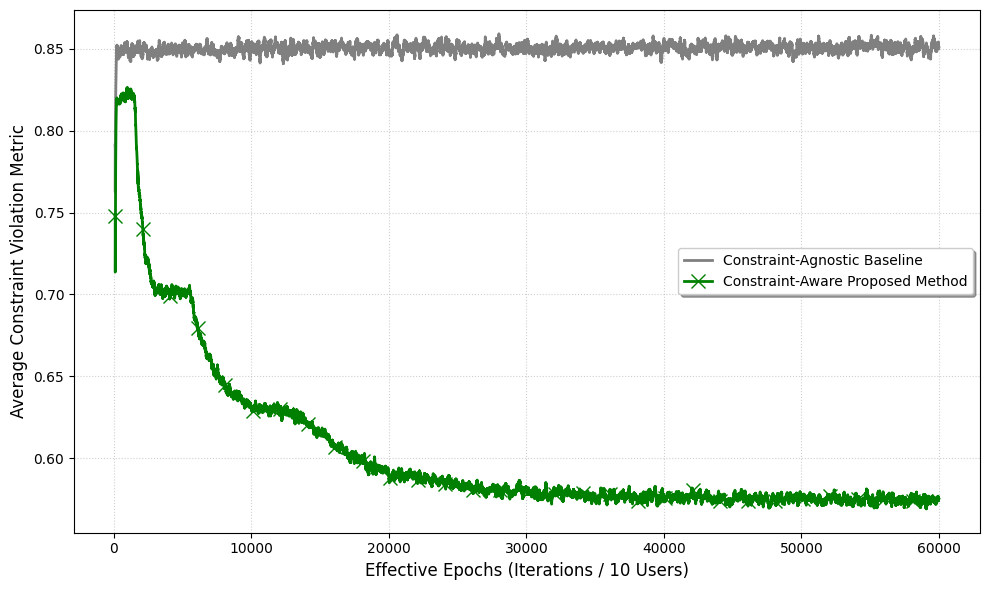

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# CẤU HÌNH BIỂU ĐỒ
# ==============================================================================
denom = N_USERS * T_SLOTS
WINDOW_SIZE = 1000
USERS_FOR_EPOCH = 10
EPOCH_LIMIT = 60000

# Hàm tính Moving Average
def moving_average(data, window_size):
    if window_size <= 1:
        return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# ==============================================================================
# XỬ LÝ DỮ LIỆU
# ==============================================================================

# 1. Tính toán dữ liệu gốc
y_baseline_raw = np.array(hist_baseline) / denom
y_proposed_raw = np.array(hist_proposed) / denom

# 2. Áp dụng SMA (Làm mượt)
y_baseline_smooth = moving_average(y_baseline_raw, WINDOW_SIZE)
y_proposed_smooth = moving_average(y_proposed_raw, WINDOW_SIZE)

# 3. Xử lý Trục X
raw_iterations = np.arange(len(hist_baseline)) * LOG_FREQ
epochs_raw = raw_iterations / USERS_FOR_EPOCH

# Cắt trục X cho khớp độ dài do SMA
if WINDOW_SIZE > 1:
    epochs_plot = epochs_raw[WINDOW_SIZE-1:]
else:
    epochs_plot = epochs_raw

# --- BƯỚC CẮT DỮ LIỆU THEO LIMIT ---
mask = epochs_plot <= EPOCH_LIMIT
epochs_view = epochs_plot[mask]
y_baseline_view = y_baseline_smooth[mask]
y_proposed_view = y_proposed_smooth[mask]

# ==============================================================================
# VẼ BIỂU ĐỒ VỚI MARKER (x VÀ *)
# ==============================================================================
plt.figure(figsize=(10, 6))

# --- TÍNH TOÁN KHOẢNG CÁCH MARKER ---
# Chia tổng số điểm cho 15 để lấy ra bước nhảy phù hợp
# Giúp biểu đồ có khoảng 15 dấu trải đều từ đầu đến cuối
mark_step = max(1, int(len(epochs_view) / 15))

# 1. Vẽ Baseline (Dùng marker 'x')
plt.plot(epochs_view, y_baseline_view,
         color='gray',
         linewidth=2,
         label=f'Constraint-Agnostic Baseline',
         marker='',            # <--- YÊU CẦU CỦA BẠN
         markevery=1000,   # Chỉ vẽ dấu cách quãng
         markersize=5,          # Kích thước dấu
         markeredgewidth=2)     # Độ dày nét của dấu x

# 2. Vẽ Proposed (Dùng marker '*')
plt.plot(epochs_view, y_proposed_view,
         color='green',
         linewidth=2,
         label=f'Constraint-Aware Proposed Method',
         marker='x',            # <--- YÊU CẦU CỦA BẠN
         markevery=20000,   # Chỉ vẽ dấu cách quãng
         markersize=10)         # Dấu sao thường cần size to hơn chút để nhìn rõ

# Trang trí
plt.xlabel(f'Effective Epochs (Iterations / {USERS_FOR_EPOCH} Users)', fontsize=12)
plt.ylabel('Average Constraint Violation Metric', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fancybox=True, shadow=True, loc='center right')

plt.tight_layout()
plt.show()